# Entrega 1 — Análise Comparativa de Representações

**Ouvidoria Inteligente: Triagem Semântica de Manifestações Cidadãs**
Aluno: Pedro Ernesto

Objetivo: comparar representações **esparsas** (Bag of Words e TF-IDF) com representações **densas** (embeddings de sentence-transformers) sobre o corpus de 40 manifestações, medindo a similaridade de cosseno nos três pares indicados no enunciado:

| Par | Manifestação A | Manifestação B | Expectativa |
|---|---|---|---|
| 1 | M003 (buraco enorme na Av. Brasil) | M017 (asfalto todo esburacado da avenida principal) | mesmo problema, vocabulário parcialmente diferente |
| 2 | M008 (posto de saúde sem médico) | M022 (falta atendimento no PSF) | mesmo problema, vocabulário quase totalmente diferente |
| 3 | M008 (posto de saúde sem médico) | M031 (lâmpada queimada na praça) | problemas sem relação |

Uma boa representação deveria dar similaridade **alta** nos pares 1 e 2 e **baixa** no par 3.

In [1]:
import json, re, unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")
Path("resultados").mkdir(exist_ok=True)

## 1. Carregamento e visão geral do corpus

In [2]:
df = pd.read_json("manifestacoes.json")
df["n_chars"] = df["texto"].str.len()
df["n_palavras"] = df["texto"].str.split().str.len()

print(f"{len(df)} manifestações | {df['n_chars'].min()}–{df['n_chars'].max()} caracteres")
print(df["categoria_oficial"].value_counts().to_string())
df.head()

40 manifestações | 121–799 caracteres
categoria_oficial
infraestrutura    9
saúde             8
meio ambiente     8
educação          8
segurança         7


,id,data,categoria_oficial,texto,n_chars,n_palavras
0,M001,2026-06-01,infraestrutura,A rua Coronel Amaral está sem asfalto há meses. Quando chove vira um lamaçal e os carros atolam. Pedimos providência...,144,23
1,M002,2026-06-04,saúde,Fui ao hospital municipal com meu filho com febre alta e esperamos mais de seis horas para ser atendidos. Não havia ...,136,24
2,M003,2026-06-07,infraestrutura,"Tem um buraco enorme na Av. Brasil, na altura do número 1200, perto do supermercado. Vários carros já furaram o pneu...",148,27
3,M004,2026-06-10,meio ambiente,"O córrego que passa atrás do conjunto Jardim das Flores está cheio de esgoto e o mau cheiro é insuportável, principa...",131,23
4,M005,2026-06-13,segurança,"A rua onde moro, no bairro São José, está completamente escura porque os postes não acendem. Já tivemos dois assalto...",149,26


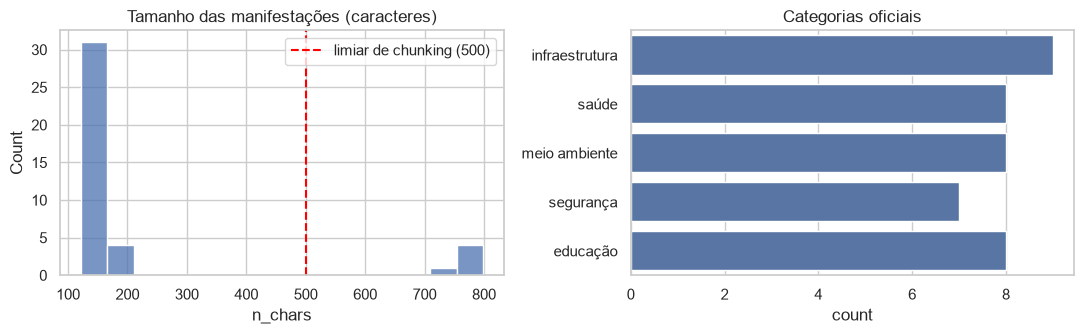

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(df["n_chars"], bins=15, ax=ax[0]).set(title="Tamanho das manifestações (caracteres)")
ax[0].axvline(500, color="red", ls="--", label="limiar de chunking (500)")
ax[0].legend()
sns.countplot(data=df, y="categoria_oficial", ax=ax[1]).set(title="Categorias oficiais", ylabel="")
plt.tight_layout()

## 2. Pré-processamento para as representações esparsas

Para BoW e TF-IDF vale a pena um pré-processamento leve: minúsculas, remoção de acentos (para que "saúde" e "saude" contem como o mesmo token) e remoção de *stopwords* do português. Sem isso, palavras como "de", "que", "está" dominam a contagem e inflam artificialmente a similaridade entre textos que não têm nada a ver.

Os embeddings **não** recebem esse pré-processamento: modelos de sentence-transformers foram treinados com texto natural e perdem informação se recebem texto sem acento e sem conectivos.

In [4]:
STOPWORDS_PT = set('''
a o os as um uma uns umas de do da dos das em no na nos nas por para com sem sob sobre
e ou mas que se ao aos à às pelo pela pelos pelas este esta isto esse essa isso aquele aquela
aquilo eu tu ele ela nós vós eles elas me te lhe nos vos lhes meu minha meus minhas seu sua
seus suas nosso nossa nossos nossas dele dela deles delas já não sim mais menos muito muitos
muita muitas pouco pouca todo toda todos todas outro outra outros outras mesmo mesma ser estar
ter haver é são está estão foi foram era eram tem têm há tinha tinham ser sendo sido
como quando onde porque porquê qual quais quem cada também ainda até desde então aqui ali lá
aí só apenas depois antes agora hoje ontem sempre nunca ha faz fazem há vem vai
'''.split())

def normalizar(texto: str) -> str:
    texto = texto.lower()
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode()
    texto = re.sub(r"[^a-z0-9\s]", " ", texto)
    return " ".join(t for t in texto.split() if t not in STOPWORDS_PT and len(t) > 1)

df["texto_norm"] = df["texto"].apply(normalizar)
df[["id", "texto_norm"]].head(3)

,id,texto_norm
0,M001,rua coronel amaral asfalto meses chove vira lamacal carros atolam pedimos providencia prefeitura urgentemente
1,M002,fui hospital municipal filho febre alta esperamos seis horas atendidos nao havia pediatra plantao
2,M003,buraco enorme av brasil altura numero 1200 perto supermercado varios carros ja furaram pneu moto caiu semana passada


## 3. Representações esparsas: BoW e TF-IDF

In [5]:
bow_vec = CountVectorizer()
X_bow = bow_vec.fit_transform(df["texto_norm"])

tfidf_vec = TfidfVectorizer(sublinear_tf=True)
X_tfidf = tfidf_vec.fit_transform(df["texto_norm"])

print(f"Vocabulário: {len(bow_vec.vocabulary_)} termos")
print(f"BoW  : matriz {X_bow.shape}, {X_bow.nnz} entradas não nulas ({100*X_bow.nnz/np.prod(X_bow.shape):.1f}% densa)")
print(f"TF-IDF: matriz {X_tfidf.shape}")

S_bow = cosine_similarity(X_bow)
S_tfidf = cosine_similarity(X_tfidf)

Vocabulário: 624 termos
BoW  : matriz (40, 624), 885 entradas não nulas (3.5% densa)
TF-IDF: matriz (40, 624)


## 4. Representações densas: embeddings

Comparo dois modelos multilíngues da biblioteca `sentence-transformers` (a dica 2 do enunciado pede pelo menos dois):

- `paraphrase-multilingual-MiniLM-L12-v2` — 384 dimensões, rápido, treinado para detectar paráfrases em 50+ idiomas (inclui português);
- `paraphrase-multilingual-mpnet-base-v2` — 768 dimensões, mesmo objetivo de treino, modelo maior e normalmente mais preciso.

Os vetores são normalizados (`normalize_embeddings=True`), então o produto interno já é a similaridade de cosseno.

In [6]:
MODELOS = {
    "MiniLM-L12": "paraphrase-multilingual-MiniLM-L12-v2",
    "mpnet-base": "paraphrase-multilingual-mpnet-base-v2",
}

modelos = {nome: SentenceTransformer(caminho) for nome, caminho in MODELOS.items()}
embeddings = {
    nome: m.encode(df["texto"].tolist(), normalize_embeddings=True, show_progress_bar=False)
    for nome, m in modelos.items()
}
S_emb = {nome: cosine_similarity(E) for nome, E in embeddings.items()}
{nome: E.shape for nome, E in embeddings.items()}

{'MiniLM-L12': (40, 384), 'mpnet-base': (40, 768)}

## 5. Similaridade de cosseno nos pares do enunciado

In [7]:
PARES = [("M003", "M017"), ("M008", "M022"), ("M008", "M031")]
idx = {mid: i for i, mid in enumerate(df["id"])}

matrizes = {"BoW": S_bow, "TF-IDF": S_tfidf, **{f"Emb {n}": S for n, S in S_emb.items()}}

linhas = []
for a, b in PARES:
    linha = {"par": f"{a} × {b}"}
    for nome, S in matrizes.items():
        linha[nome] = round(float(S[idx[a], idx[b]]), 3)
    tokens_a = set(df.loc[idx[a], "texto_norm"].split())
    tokens_b = set(df.loc[idx[b], "texto_norm"].split())
    linha["tokens em comum"] = ", ".join(sorted(tokens_a & tokens_b)) or "(nenhum)"
    linhas.append(linha)

tabela_pares = pd.DataFrame(linhas).set_index("par")
tabela_pares

,BoW,TF-IDF,Emb MiniLM-L12,Emb mpnet-base,tokens em comum
par,,,,,
M003 × M017,0.295,0.247,0.757,0.842,"av, brasil, carros, moto, perto"
M008 × M022,0.123,0.122,0.609,0.734,"atendimento, geisel"
M008 × M031,0.067,0.021,0.228,0.388,bairro


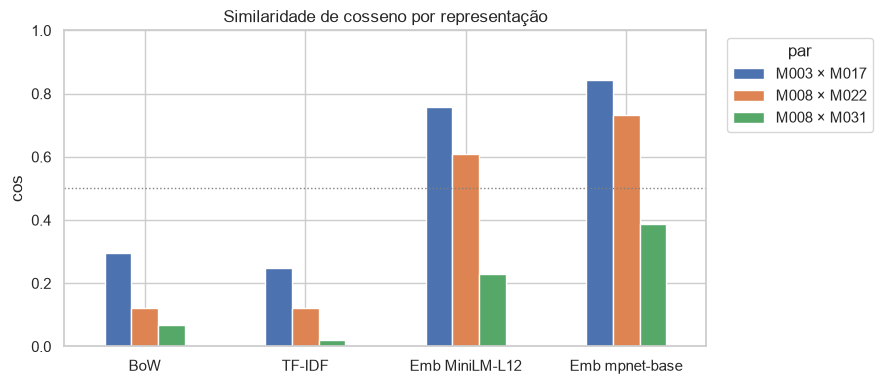

In [8]:
ax = tabela_pares.drop(columns="tokens em comum").T.plot.bar(figsize=(9, 4), rot=0)
ax.set(title="Similaridade de cosseno por representação", ylabel="cos", ylim=(0, 1))
ax.axhline(0.5, color="gray", ls=":", lw=1)
ax.legend(title="par", bbox_to_anchor=(1.02, 1))
plt.tight_layout()

A coluna *tokens em comum* explica o comportamento das representações esparsas: BoW e TF-IDF só enxergam sobreposição lexical. Onde não há palavra em comum a similaridade é exatamente **zero**, não importa o quão parecidos os problemas sejam. Nos três pares acima sobra sempre alguma palavra ("atendimento" e "geisel" em M008 × M022, só "bairro" em M008 × M031), e é isso que sustenta os valores baixos, mas não nulos, das esparsas. Os embeddings, por outro lado, foram treinados para aproximar paráfrases, então conseguem ligar "posto sem médico" a "falta atendimento no PSF" com apenas duas palavras em comum, mantendo M008 × M031 bem abaixo.

Os textos completos dos pares, para leitura:

In [9]:
for a, b in PARES:
    print(f"── {a} × {b} ──")
    print(f"{a}: {df.loc[idx[a], 'texto']}")
    print(f"{b}: {df.loc[idx[b], 'texto']}\n")

── M003 × M017 ──
M003: Tem um buraco enorme na Av. Brasil, na altura do número 1200, perto do supermercado. Vários carros já furaram o pneu e uma moto caiu semana passada.
M017: O asfalto da avenida principal está todo esburacado, principalmente na Av. Brasil perto do mercado. Os buracos estão danificando os carros e causando acidentes de moto.

── M008 × M022 ──
M008: O posto de saúde do bairro Geisel está sem médico há duas semanas. Chegamos às 5 da manhã, pegamos ficha e depois avisam que não vai ter atendimento.
M022: Falta atendimento no PSF do Geisel. Faz quinze dias que nenhum profissional aparece na unidade; a gente madruga na fila, pega senha e volta pra casa sem consulta.

── M008 × M031 ──
M008: O posto de saúde do bairro Geisel está sem médico há duas semanas. Chegamos às 5 da manhã, pegamos ficha e depois avisam que não vai ter atendimento.
M031: A lâmpada do poste da praça do bairro Torre está queimada há mais de um mês. A praça fica toda escura e as pessoas pararam de f

## 6. Vizinhos mais próximos de M008

Outra forma de sentir a diferença: quem cada representação considera "mais parecido" com M008 (posto de saúde sem médico)? Idealmente a lista deveria ser dominada por manifestações de saúde, com M022 (a duplicata real) no topo.

In [10]:
def vizinhos(S, alvo, k=5):
    i = idx[alvo]
    ordem = np.argsort(-S[i])
    ordem = [j for j in ordem if j != i][:k]
    return pd.DataFrame({
        "id": df["id"].iloc[ordem].values,
        "categoria": df["categoria_oficial"].iloc[ordem].values,
        "sim": np.round(S[i, ordem], 3),
        "texto": df["texto"].iloc[ordem].str[:70].values + "…",
    })

for nome, S in matrizes.items():
    print(f"\n=== {nome} ===")
    display(vizinhos(S, "M008"))


=== BoW ===


,id,categoria,sim,texto
0,M035,meio ambiente,0.218,Coleta de lixo não está acontecendo na rua Padre Meira. Faz quase duas…
1,M037,saúde,0.207,O agente de saúde não visita nossa rua no bairro Alto do Mateus há mes…
2,M006,saúde,0.160,Escrevo para relatar uma situação que se repete no posto de saúde do b…
3,M030,educação,0.143,A biblioteca da escola municipal do bairro Cristo Redentor está fechad…
4,M039,educação,0.134,Faltam vagas em creche no bairro Grotão. Estou na fila de espera há um…



=== TF-IDF ===


,id,categoria,sim,texto
0,M035,meio ambiente,0.131,Coleta de lixo não está acontecendo na rua Padre Meira. Faz quase duas…
1,M022,saúde,0.122,Falta atendimento no PSF do Geisel. Faz quinze dias que nenhum profiss…
2,M037,saúde,0.103,O agente de saúde não visita nossa rua no bairro Alto do Mateus há mes…
3,M006,saúde,0.093,Escrevo para relatar uma situação que se repete no posto de saúde do b…
4,M040,meio ambiente,0.067,Quero denunciar a poluição sonora e ambiental de uma fábrica de blocos…



=== Emb MiniLM-L12 ===


,id,categoria,sim,texto
0,M002,saúde,0.660,Fui ao hospital municipal com meu filho com febre alta e esperamos mai…
1,M022,saúde,0.609,Falta atendimento no PSF do Geisel. Faz quinze dias que nenhum profiss…
2,M032,saúde,0.592,Marquei consulta com cardiologista pelo SUS em fevereiro e só consegui…
3,M037,saúde,0.584,O agente de saúde não visita nossa rua no bairro Alto do Mateus há mes…
4,M006,saúde,0.533,Escrevo para relatar uma situação que se repete no posto de saúde do b…



=== Emb mpnet-base ===


,id,categoria,sim,texto
0,M022,saúde,0.734,Falta atendimento no PSF do Geisel. Faz quinze dias que nenhum profiss…
1,M002,saúde,0.619,Fui ao hospital municipal com meu filho com febre alta e esperamos mai…
2,M037,saúde,0.603,O agente de saúde não visita nossa rua no bairro Alto do Mateus há mes…
3,M025,saúde,0.579,A UPA do Oitizeiro está sem aparelho de raio-x funcionando. Fui encami…
4,M039,educação,0.545,Faltam vagas em creche no bairro Grotão. Estou na fila de espera há um…


## 7. Análise global: coerência com as categorias oficiais

Para não depender só de três pares, mede-se em todo o corpus a similaridade média entre manifestações **da mesma categoria** e **de categorias diferentes**. Uma representação útil para triagem deveria ter uma separação clara entre as duas (razão intra/inter alta).

In [11]:
cats = df["categoria_oficial"].to_numpy(dtype=object)
mesma = cats[:, None] == cats[None, :]
mascara_off = ~np.eye(len(df), dtype=bool)

resumo = []
for nome, S in matrizes.items():
    intra = S[mesma & mascara_off].mean()
    inter = S[~mesma].mean()
    resumo.append({"representação": nome, "sim. intra-categoria": round(intra, 3),
                   "sim. inter-categoria": round(inter, 3), "razão intra/inter": round(intra / inter, 2)})
tabela_global = pd.DataFrame(resumo).set_index("representação")
tabela_global

,sim. intra-categoria,sim. inter-categoria,razão intra/inter
representação,,,
BoW,0.085,0.037,2.33
TF-IDF,0.051,0.017,2.94
Emb MiniLM-L12,0.429,0.252,1.70
Emb mpnet-base,0.509,0.330,1.54


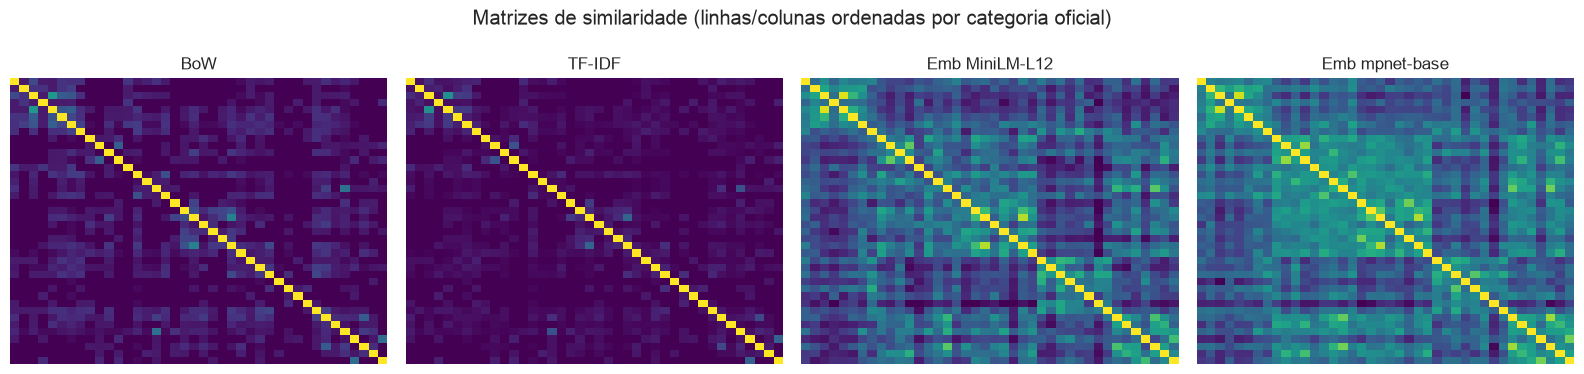

In [12]:
fig, axes = plt.subplots(1, len(matrizes), figsize=(4 * len(matrizes), 3.8), sharey=True)
ordem = df.sort_values("categoria_oficial").index
for ax, (nome, S) in zip(axes, matrizes.items()):
    sns.heatmap(S[np.ix_(ordem, ordem)], ax=ax, cmap="viridis", vmin=0, vmax=1, cbar=False,
                xticklabels=False, yticklabels=False)
    ax.set_title(nome)
fig.suptitle("Matrizes de similaridade (linhas/colunas ordenadas por categoria oficial)")
plt.tight_layout()

Nas matrizes ordenadas por categoria, blocos mais claros na diagonal indicam que manifestações da mesma categoria se parecem entre si. Nas representações esparsas a matriz é quase toda escura (a maioria dos pares tem similaridade perto de zero) e os blocos mal aparecem; nos embeddings os blocos ficam visíveis, embora com "vazamento" entre categorias vizinhas, como infraestrutura × segurança (iluminação pública aparece nas duas).

## 8. Persistência dos resultados (usados no relatório)

In [13]:
resultados = {
    "pares": tabela_pares.drop(columns="tokens em comum").to_dict(orient="index"),
    "tokens_em_comum": tabela_pares["tokens em comum"].to_dict(),
    "global": tabela_global.to_dict(orient="index"),
    "modelos": MODELOS,
    "vocabulario": len(bow_vec.vocabulary_),
}
with open("resultados/entrega1.json", "w", encoding="utf-8") as f:
    json.dump(resultados, f, ensure_ascii=False, indent=2)
print("salvo em resultados/entrega1.json")

salvo em resultados/entrega1.json


## 9. Conclusão: limitações de cada abordagem

**Bag of Words.** Representa o texto como contagem de palavras, sem ordem e sem semântica. Funciona apenas quando os cidadãos usam as mesmas palavras: no par M003 × M017 há alguma sobreposição ("av", "brasil", "carros", "moto", "perto") e a similaridade fica moderada, mas note que "buraco", "buracos" e "esburacado" contam como tokens diferentes (sem stemming, a variação morfológica do português também é invisível); no par M008 × M022 a similaridade cai para pouco mais de 0,1 porque "posto de saúde sem médico" e "falta atendimento no PSF" só compartilham "geisel" e "atendimento", ainda que descrevam exatamente o mesmo problema no mesmo bairro. Além disso, BoW é sensível a tamanho: manifestações longas acumulam contagens e ficam artificialmente "parecidas" com muitas outras. O par M008 × M031 recebe similaridade baixa, mas pelo motivo errado (não por o modelo entender que são assuntos diferentes, e sim por os dois textos só compartilharem a palavra genérica "bairro").

**TF-IDF.** Corrige parte do problema do BoW ao pesar menos palavras frequentes no corpus e mais palavras raras. Isso ajuda a ignorar termos genéricos como "rua", "bairro", "prefeitura", e os vizinhos de M008 ficam ligeiramente melhores. Mas a limitação fundamental permanece: TF-IDF continua sendo puramente lexical. Sinônimos, paráfrases e abreviações ("posto" vs. "PSF", "esburacado" vs. "buraco") continuam ortogonais. Em um corpus pequeno como este (40 documentos) o IDF também é instável: uma palavra que aparece em 2 documentos ganha peso enorme e pode aproximar textos por coincidência.

**Embeddings (MiniLM e mpnet).** Representam cada manifestação por um vetor denso aprendido para que paráfrases fiquem próximas. É a única abordagem que aproxima M008 × M022 (0,61 no MiniLM e 0,73 no mpnet, contra 0,12 nas esparsas) mantendo M008 × M031 bem abaixo (0,23 e 0,39), e a única que produz blocos por categoria na matriz global. Mesmo assim, 0,61 e 0,73 ficam longe do 0,85 sugerido no enunciado, e na lista de vizinhos de M008 o MiniLM coloca M022 em segundo lugar, atrás de M002 (hospital lotado); só o mpnet a coloca no topo. Esse par volta como falso negativo na Entrega 2. As limitações são de outra natureza: (i) custo computacional e dependência de um modelo pré-treinado, que precisa ser baixado e mantido; (ii) opacidade, porque não dá para explicar ao ouvidor "estas manifestações foram agrupadas por causa da palavra X"; (iii) o modelo é multilíngue genérico, então detalhes locais como nomes de bairros, siglas municipais e gírias regionais nem sempre são bem representados; (iv) textos longos sofrem com o limite de tokens do modelo (128 para o MiniLM), o que motiva o chunking da Entrega 3; e (v) como visto na matriz global, categorias semanticamente próximas (infraestrutura e segurança, saúde e meio ambiente) se misturam, o que é correto do ponto de vista linguístico mas nem sempre coincide com a divisão administrativa da prefeitura.

Na prática, para a Ouvidoria a recomendação é usar embeddings como representação principal para busca e detecção de duplicatas, mantendo TF-IDF como recurso complementar barato para explicar resultados (destacar termos em comum) e para filtros por palavra-chave exata, como nomes de rua.